# Bermudan Option Pricing — Primal-Dual Bounds

This notebook reproduces the main results of the project:
- **Lower bound**: Longstaff-Schwartz Monte Carlo (LSMC)
- **Upper bound**: Neural dual martingale via stochastic integral parametrization
- **Reference**: Binomial tree on the same exercise grid

Two figures:
1. Convergence of bounds as number of paths N increases
2. Gap comparison across all upper bound methods at fixed N

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from bermudan.simulate import simulate_gbm_paths
from bermudan.payoff import put_payoff
from bermudan.lsmc import lsmc_price
from bermudan.binomial import binomial_price
from bermudan.dual import compute_upper_bound, compute_upper_bound_with_scaling, ci
from bermudan.neural_martingale import train_neural_martingale, construct_neural_martingale

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

In [2]:
# --- parameters ---
S0    = 100
K     = 100
r     = 0.05
sigma = 0.2
T     = 1.0
n_steps = 10

SEED    = 42
N_VALUES = [1000, 2000, 4000, 8000, 16000]
N_FIXED  = 8000   # used for the gap bar chart

# binomial reference — same 10-step grid
binom_ref = binomial_price(S0, K, r, sigma, T, n_steps)
print(f'Binomial reference (n_steps={n_steps}): {binom_ref:.4f}')

Binomial reference (n_steps=10): 6.0043


## Figure 1 — Convergence of bounds with number of paths

In [3]:
results = []

for N in N_VALUES:
    np.random.seed(SEED)
    torch.manual_seed(SEED)

    # use half for training, half for evaluation
    train_paths = simulate_gbm_paths(S0, r, sigma, T, n_steps, N)
    test_paths  = simulate_gbm_paths(S0, r, sigma, T, n_steps, N)

    # lower bound
    lower, _, _, vp = lsmc_price(test_paths, K, r, T, put_payoff)
    lower_ci = ci(vp[:, 0])

    # neural upper bound
    h_net = train_neural_martingale(
        train_paths, put_payoff, K, r, sigma, T,
        n_epochs=30, batch_size=min(2048, N), lr=1e-3, device='cpu'
    )
    M = construct_neural_martingale(test_paths, h_net, K, r, sigma, T)
    dt   = T / n_steps
    disc = np.exp(-r * dt * np.arange(n_steps + 1))
    samples_upper = np.max(put_payoff(test_paths, K) * disc - M, axis=1)
    upper     = float(np.mean(samples_upper))
    upper_ci  = float(ci(samples_upper))

    results.append({
        'N': N,
        'lower': lower, 'lower_ci': lower_ci,
        'upper': upper, 'upper_ci': upper_ci,
    })
    print(f'N={N:>6}  lower={lower:.4f}±{lower_ci:.4f}  upper={upper:.4f}±{upper_ci:.4f}')

N=  1000  lower=5.6270±0.4470  upper=8.7802±0.4062
N=  2000  lower=5.7673±0.3191  upper=8.7529±0.2764
N=  4000  lower=5.7288±0.2219  upper=7.9760±0.0974
N=  8000  lower=5.8782±0.1598  upper=6.7494±0.0442
N= 16000  lower=5.8803±0.1136  upper=6.5203±0.0306


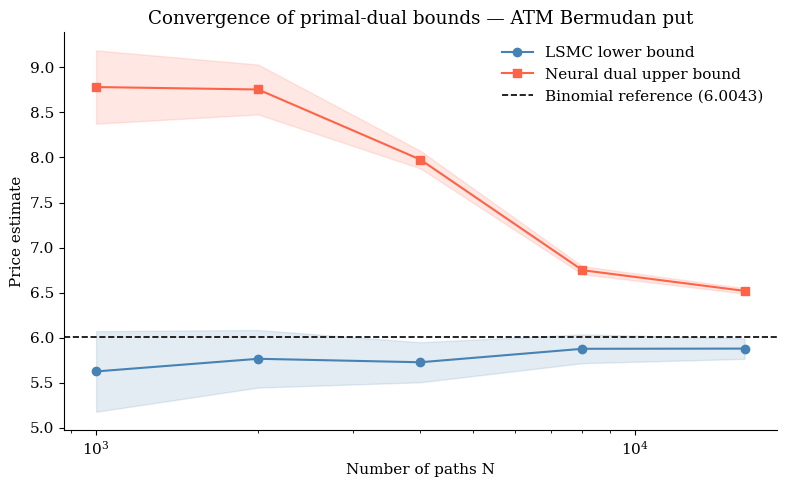

In [4]:
Ns      = [r['N']        for r in results]
lowers  = [r['lower']    for r in results]
l_cis   = [r['lower_ci'] for r in results]
uppers  = [r['upper']    for r in results]
u_cis   = [r['upper_ci'] for r in results]

fig, ax = plt.subplots(figsize=(8, 5))

# lower bound
ax.plot(Ns, lowers, 'o-', color='steelblue', label='LSMC lower bound')
ax.fill_between(Ns,
    [l - c for l, c in zip(lowers, l_cis)],
    [l + c for l, c in zip(lowers, l_cis)],
    alpha=0.15, color='steelblue')

# neural upper bound
ax.plot(Ns, uppers, 's-', color='tomato', label='Neural dual upper bound')
ax.fill_between(Ns,
    [u - c for u, c in zip(uppers, u_cis)],
    [u + c for u, c in zip(uppers, u_cis)],
    alpha=0.15, color='tomato')

# binomial reference
ax.axhline(binom_ref, color='black', linestyle='--', linewidth=1.2,
           label=f'Binomial reference ({binom_ref:.4f})')

ax.set_xlabel('Number of paths N')
ax.set_ylabel('Price estimate')
ax.set_title('Convergence of primal-dual bounds — ATM Bermudan put')
ax.legend(frameon=False)
ax.set_xscale('log')

plt.tight_layout()
plt.savefig('convergence.png', dpi=150, bbox_inches='tight')
plt.show()

## Figure 2 — Gap comparison across upper bound methods at fixed N

In [5]:
np.random.seed(SEED)
torch.manual_seed(SEED)

train_paths = simulate_gbm_paths(S0, r, sigma, T, n_steps, N_FIXED)
test_paths  = simulate_gbm_paths(S0, r, sigma, T, n_steps, N_FIXED)

lower, _, _, vp = lsmc_price(test_paths, K, r, T, put_payoff)

upper_doob,   hw_doob   = compute_upper_bound(test_paths, put_payoff, K, r, T)
upper_scaled, hw_scaled = compute_upper_bound_with_scaling(test_paths, put_payoff, K, r, T)

h_net = train_neural_martingale(
    train_paths, put_payoff, K, r, sigma, T,
    n_epochs=30, batch_size=2048, lr=1e-3, device='cpu'
)
M = construct_neural_martingale(test_paths, h_net, K, r, sigma, T)
dt   = T / n_steps
disc = np.exp(-r * dt * np.arange(n_steps + 1))
samples_nn = np.max(put_payoff(test_paths, K) * disc - M, axis=1)
upper_nn = float(np.mean(samples_nn))
hw_nn    = float(ci(samples_nn))

methods = ['Doob dual', 'Scaled dual', 'Neural dual']
gaps    = [upper_doob - lower, upper_scaled - lower, upper_nn - lower]
hws     = [hw_doob, hw_scaled, hw_nn]
colors  = ['#aec6cf', '#6fa8c9', 'tomato']

print(f'\nN={N_FIXED} — lower bound = {lower:.4f}')
print(f'{"Method":<15} {"Upper":>8} {"±CI":>8} {"Gap":>8}')
print('-' * 42)
for m, g, u, hw in zip(methods, gaps,
    [upper_doob, upper_scaled, upper_nn], hws):
    print(f'{m:<15} {u:>8.4f} {hw:>8.4f} {g:>8.4f}')


N=8000 — lower bound = 5.8782
Method             Upper      ±CI      Gap
------------------------------------------
Doob dual        19.7717   0.4415  13.8935
Scaled dual       8.5867   0.1239   2.7086
Neural dual       6.7494   0.0442   0.8712


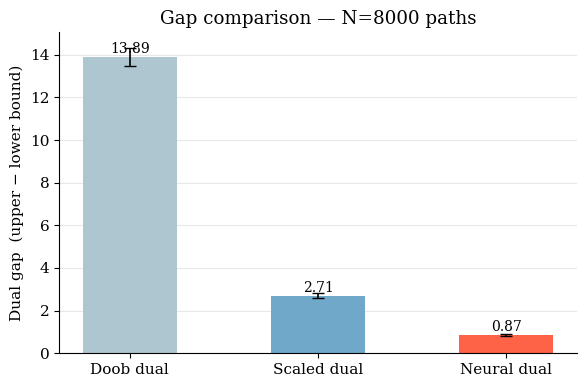

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(methods, gaps, color=colors, width=0.5, zorder=2)
ax.errorbar(methods, gaps, yerr=hws, fmt='none',
            color='black', capsize=4, linewidth=1.2, zorder=3)

for bar, gap in zip(bars, gaps):
    ax.text(bar.get_x() + bar.get_width() / 2,
            gap + max(hws) * 0.1,
            f'{gap:.2f}', ha='center', va='bottom', fontsize=10)

ax.set_ylabel('Dual gap  (upper − lower bound)')
ax.set_title(f'Gap comparison — N={N_FIXED} paths')
ax.grid(axis='y', alpha=0.3, zorder=1)

plt.tight_layout()
plt.savefig('gap_comparison.png', dpi=150, bbox_inches='tight')
plt.show()